In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
import os

#path = '/mnt/d/GoogleDrive/AI_learning/Week1/3_makemore_p2'
file = 'names.txt'
#filepath = os.path.join(path, file)
words = open(file, 'r').read().splitlines()
print(words[:8])
print(len(words))

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']
32033


In [2]:
chars = sorted(list(set(''.join(words))))
print(chars)
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)

['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [3]:
block_size = 3  # context length: how many characters do we take to predict next?
def build_dataset(words):    
    block_size = 3  # context length: how many characters do we take to predict next?
    X, Y = [], []
    for w in words:
        #print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            #print(''.join(itos[i] for i in context), '---->', itos[ix])
            context = context[1:] + [ix]    # shift one charater to the left and append the new character

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, X.dtype, Y.shape, Y.dtype)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.int64 torch.Size([182625]) torch.int64
torch.Size([22655, 3]) torch.int64 torch.Size([22655]) torch.int64
torch.Size([22866, 3]) torch.int64 torch.Size([22866]) torch.int64


In [ ]:
# # now made respectable
# n_embd = 10     # the dimensionality of the character embedding vectors
# n_hidden = 200  # the number of neurons in the hidden layer of the MLP
# g = torch.Generator().manual_seed(2147483647)
# C = torch.randn((vocab_size, n_embd), generator=g)        # each character gets mapped to an n_embd-dimensional vector
# W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)   # 3 is the number of input characters, n_hidden is the number of hidden neurons
# b1 = torch.randn(n_hidden, generator=g)
# W2 = torch.randn((n_hidden, vocab_size), generator=g)
# b2 = torch.randn(vocab_size, generator=g)
# parameters = [C, W1, b1, W2, b2]
# #print([p.shape for p in parameters])
# print(sum(p.nelement() for p in parameters))
# for p in parameters:
#     p.requires_grad = True

# MLP revisited
n_embd = 10     # the dimensionality of the character embedding vectors
n_hidden = 200  # the number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd),               generator=g)            # each character gets mapped to an n_embd-dimensional vector
W1 = torch.randn((n_embd * block_size, n_hidden),   generator=g) * (5/3) / ((n_embd * block_size)**0.5) #* 0.2           # 3 is the number of input characters, n_hidden is the number of hidden neurons
#b1 = torch.randn(n_hidden,                          generator=g) * 0.01    # no need becuase of normalization
W2 = torch.randn((n_hidden, vocab_size),            generator=g) * 0.01     # small but not zero
b2 = torch.randn(vocab_size,                        generator=g) * 0

# BatchNorm parameters:
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))         # not trained by backward propagation, but updated
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, W2, b2, bngain, bnbias]
#print([p.shape for p in parameters])
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

# but how to get the scaling parameters? 

12297


In [5]:
(5/3) / (30**0.5) # Gain / sqrt(fan_mode)

0.3042903097250923

tensor(-0.0007) tensor(1.0047)
tensor(-0.0040) tensor(1.0343)


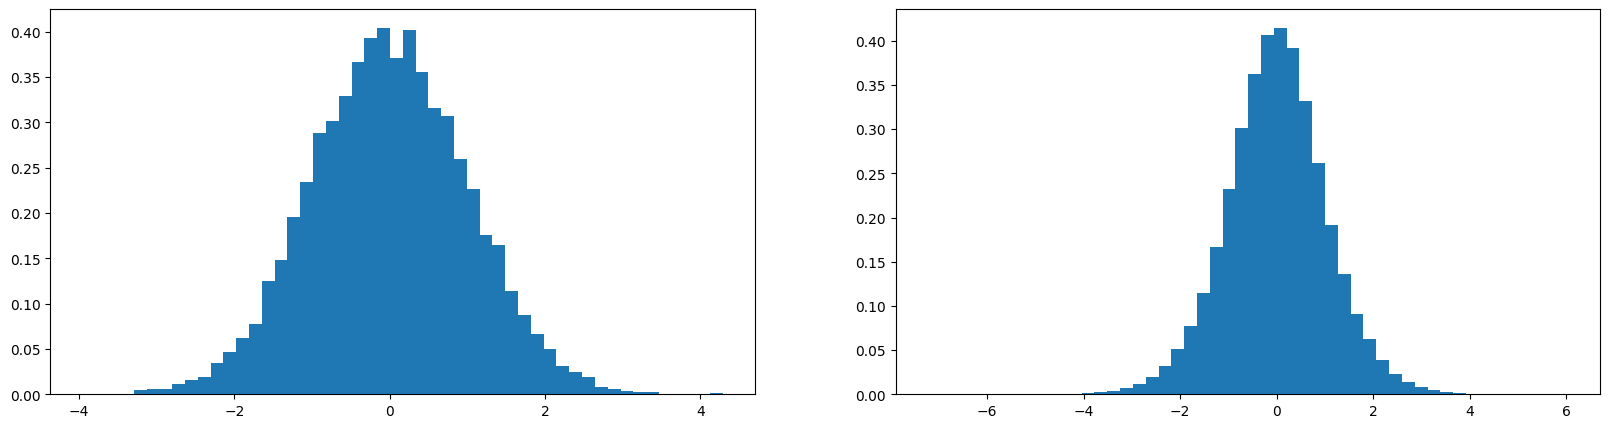

In [6]:
x = torch.randn(1000, 10)
#w = torch.randn(10, 200)
w = torch.randn(10, 200) / 10**0.5  # /sqrt(n) where n is the number of inputs to the neuron
y = x @ w                   # predicted y
print(x.mean(), x.std())    # ~sd=1 originally
print(y.mean(), y.std())    # ~sd=3.19 originally. What we need is to tune this to be one
plt.figure(figsize=(20,5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True);
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True);

In [ ]:
max_step = 200000
batch_size = 32
lossi = []
for i in range(max_step):
    #minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # forward pass
    emb = C[Xb]  
    embcat = emb.view(emb.shape[0], -1)  # concatenate the 3 character embeddings together
    hpreact = embcat @ W1 + #b1           # dimensions: (batch_size, n_embd * block_size) @ (n_embd * block_size, hidden_size) = (batch_size, hidden_size)
    #hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias # normalization to Gaussian (this form is inefficient)
    
    # Batch normalization: use the batch statistics to normalize, then apply gain and bias (BatchNorm1d)
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias        # instead of b1, now bnbias is now dominant

    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani       # 0.001 is called momentum, this step is exactly tracking_running_status = True in BatchNorm1d
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi

    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)       
    #print(loss.item())

    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update after track stats
    #lr = 0.01
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad  

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_step}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    #break
print(loss.item())

      0/200000: 3.3147
  10000/200000: 2.1984
  20000/200000: 2.3375
  30000/200000: 2.4359
  40000/200000: 2.0119
  50000/200000: 2.2595
  60000/200000: 2.4775
  70000/200000: 2.1020
  80000/200000: 2.2788
  90000/200000: 2.1862
 100000/200000: 1.9474
 110000/200000: 2.3010
 120000/200000: 1.9837
 130000/200000: 2.4523
 140000/200000: 2.3839
 150000/200000: 2.1987
 160000/200000: 1.9733
 170000/200000: 1.8668
 180000/200000: 1.9973
 190000/200000: 1.8347
2.4315383434295654


In [20]:
print(hpreact.shape)
print(hpreact.mean(0, keepdim=True).shape)
print(hpreact.std(0, keepdim=True).shape)

torch.Size([32, 200])
torch.Size([1, 200])
torch.Size([1, 200])


In [21]:
# initalization loss should be around -log(1/27) since we have 27 characters in the vocabulary (26 letters + 1 for the dot). 27.88 is too high 
-torch.tensor(1/27.0).log()

logits[0]   # showing that the logits are too high. To achieve a loss of around 3.3, the logits should be around 0 (since log(1/27) is about -3.3). 

tensor([-2.9432,  1.7033, -0.1490, -0.6337, -0.2506,  1.9912, -1.0582, -1.1586,
        -0.0168,  2.3002, -2.0891, -1.5071,  2.9150,  1.6254,  2.9859,  0.7832,
        -0.6382, -3.9366,  1.3895,  1.1865,  0.8465, -1.4758,  0.3449, -2.4001,
        -2.2058,  2.5447, -0.3120], grad_fn=<SelectBackward0>)

In [22]:
# softmax is defined for floating point tensors; integer (Long) logits will error
logits = torch.tensor([1.0, 1.0, 1.0, 1.0])  # float32 by default
#logits = torch.randn(4) * 100
probs = torch.softmax(logits, dim=0)
loss = -probs[2].log()
logits, probs, loss

(tensor([1., 1., 1., 1.]),
 tensor([0.2500, 0.2500, 0.2500, 0.2500]),
 tensor(1.3863))

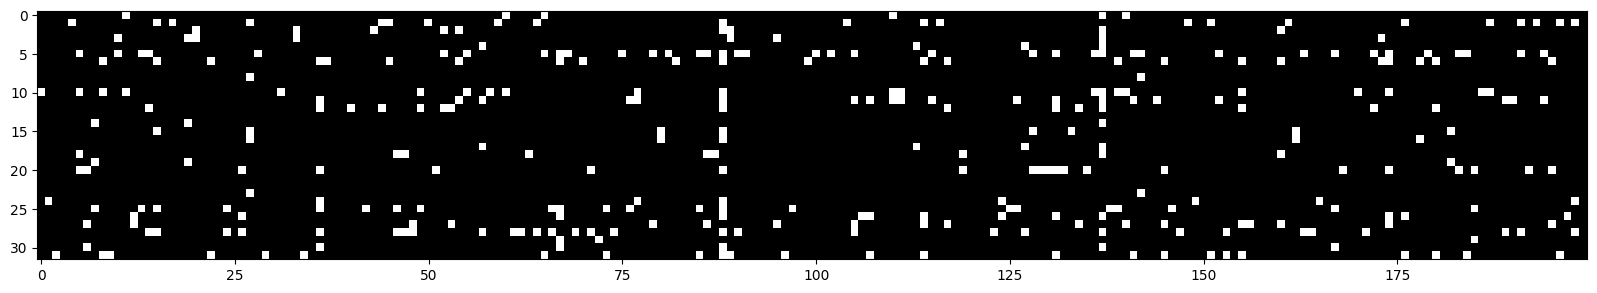

In [23]:
plt.figure(figsize=(20, 10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')    # The white pixels are dead neurons.

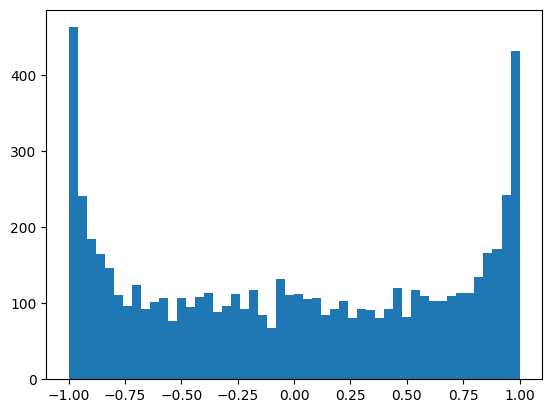

In [24]:
# h
plt.hist(h.view(-1).tolist(), 50);  # most values located at 1 and -1. This makes the gradients are destroyed = nothing will be learned. 

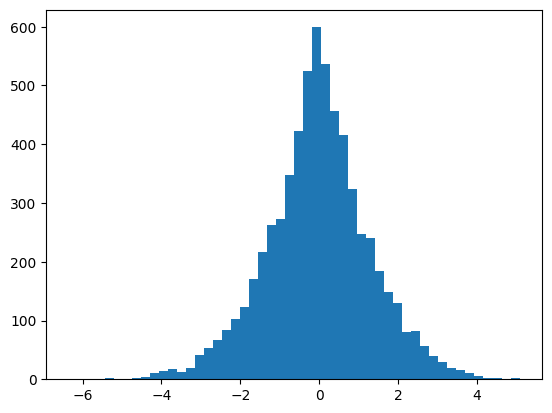

In [25]:
plt.hist(hpreact.view(-1).tolist(), 50);

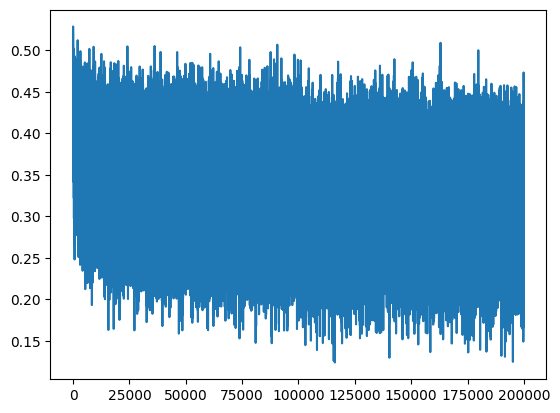

In [26]:
plt.plot(lossi)

In [34]:
# calibrate the batch norm at the end of training
# but no one will seprately do this, we will just use the running mean/std that is tracked during training.
with torch.no_grad():
    # pass the training set through
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0], -1)  # concatenate the 3 character embeddings together
    hpreact = embcat @ W1 + b1           
    # measure the mean/std over the entire training set
    bnmean = hpreact.mean(0, keepdim=True)
    bnstd = hpreact.std(0, keepdim=True)

print(bnmean_running - bnmean)
print(bnstd_running - bnstd)

tensor([[-1.8457e-02,  9.6699e-03,  1.3205e-02, -3.7944e-04,  2.8148e-03,
         -7.5715e-03, -4.7863e-03, -1.4851e-02, -1.2270e-02, -2.0858e-02,
         -1.0146e-02, -5.3916e-03, -1.0906e-02, -9.7863e-03,  5.8073e-03,
          1.7229e-02,  3.9698e-03, -1.8039e-02, -2.1799e-02, -8.5149e-03,
         -2.5576e-03,  1.9804e-02, -1.2073e-03,  3.5375e-04, -1.1384e-04,
          5.8326e-04,  4.2543e-03, -5.3596e-03, -1.2066e-03,  4.8618e-03,
         -1.1549e-02, -2.9923e-03,  2.2931e-03, -2.0714e-03, -1.0961e-03,
          7.9870e-06,  5.2086e-04, -1.1691e-02,  3.9431e-03,  5.9930e-03,
         -8.0413e-03, -2.3136e-02, -2.3873e-03,  3.3129e-03,  2.6839e-03,
          8.5821e-03, -2.1620e-03, -1.5051e-02, -6.1703e-03, -1.2039e-02,
         -1.4198e-02, -6.8441e-03, -9.5817e-03, -4.5052e-04, -8.3036e-03,
         -2.1738e-03, -1.8871e-03,  1.7536e-03,  1.6405e-02,  4.0179e-04,
         -1.5224e-02, -6.6500e-03, -7.3845e-03, -5.0495e-03, -5.6636e-04,
         -1.5728e-02, -5.9655e-03, -7.

In [35]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x]          # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1)  # concatenate the 3 character embeddings together, concat into (N, block_size * n_embd)
    hpreact = embcat @ W1 + b1           # dimensions: (batch_size, n_embd * block_size) @ (n_embd * block_size, hidden_size) = (batch_size, hidden_size)
    #hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias # normalization to Gaussian (this form is inefficient)
    #hpreact = (hpreact - bnmean) / bnstd * bngain + bnbias # use the calibrated mean/std to normalize
    hpreact = (hpreact - bnmean_running) / bnstd_running * bngain + bnbias # because running is very close to the calibrated, we can use running mean/std to normalize
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2                # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(f'{split} loss: {loss.item():.4f}')

split_loss('train')
split_loss('val')

train loss: 2.0666
val loss: 2.1051


loss log
orginal
train  = 2.124
val = 2.168

fix softmax confidently wrong:
train = 2.07
val = 2.13

fix tanh layer too saturated at init:
train = 2.0356
val loss = 2.1027

use semi-principled "kaiming-init" instead of hacky init:
train = 2.037644
val = 2.1681964

add a batch norm layer
train = 2.0668
val - 2.1048 

In [36]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
        emb = C[torch.tensor([context])] # (1, block_size, d)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    #print(out)
    print(''.join(itos[i] for i in out))        # this is more better than the previous names generated by previos lecture.

carpahzarbriq.
shlimrixtts.
lusslaysierricnenddhn.
frtivgqliyah.
farrichaiirdnsleggyu.
bmanvitte.
sants.
lustvi.
vabbuwatth.
giidryxiidh.
sulipsables.
falia.
gtas.
jasfaylahas.
bduricsydustquovozswy.
bjumillassannyks.
sadlusoffordst.
sramsryndlycpllmanraq.
shelseombriyabhda.
ffxrdustvebndvi.


In [ ]:
# Let's train a deeper network

Homeworks:
1. Understand the logic of this code
2. Tindy up in notebook in a py script
3. (a) use torch.nn to simpify the scripts; (b) add to 5 hidden layers to train the model; (c) include examination on the saturation, distributions and learning rate of all layers.